In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
import warnings
warnings.filterwarnings('ignore')

# Loading the data

In [3]:
df = pd.read_csv("../data/imputed_data.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df = df.set_index('Timestamp', drop=True)
df.sort_index(inplace=True)

## Choosing exogenous predictors

Same predictors as the ARX notebook: irradiation, PV/ambient temperature, cloud cover and humidity.

In [4]:
exog_cols = [
       'Wind_Dir_deg', 'Wind_Speed_ms', 'Humidity_pct',
       'Outdoor_Temp_C', 'Solar_Radiation_Wm2',
       'PM10_ugm3', 'PM25_ugm3', 'Rain_mm',
       'dew_point_2m (°C)'
]

df[['DC'] + exog_cols].corr()['DC']

DC                     1.000000
Wind_Dir_deg          -0.183805
Wind_Speed_ms          0.214277
Humidity_pct          -0.290730
Outdoor_Temp_C         0.235853
Solar_Radiation_Wm2    0.972456
PM10_ugm3             -0.062695
PM25_ugm3             -0.056337
Rain_mm               -0.054337
dew_point_2m (°C)     -0.068966
Name: DC, dtype: float64

# Splitting the data

Train: (5152, 12), Test: (1471, 12), Validation: (737, 12)


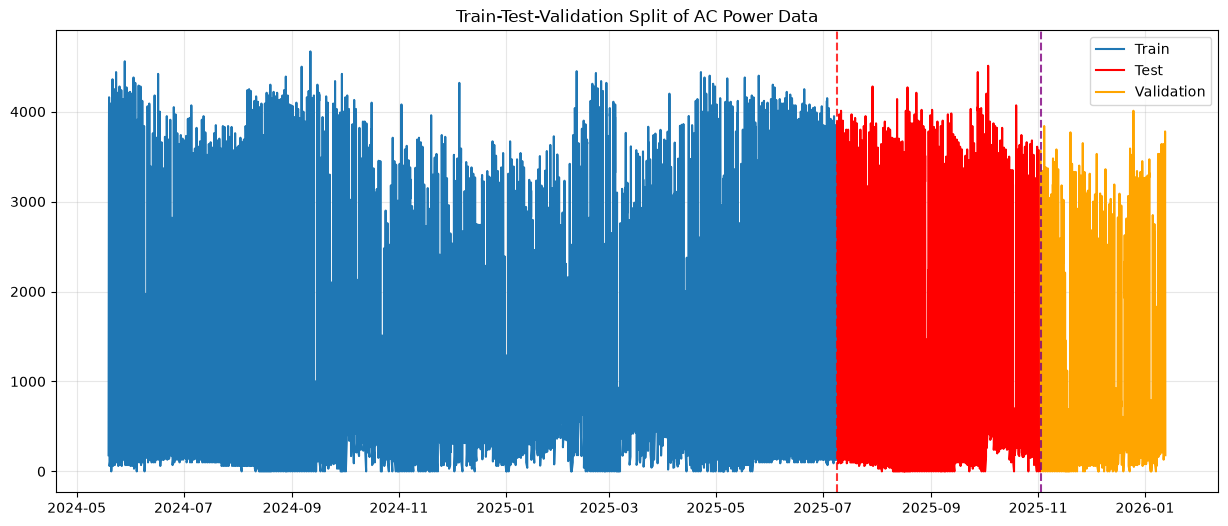

In [5]:
train_percent = 0.7
test_percent = 0.2

n_total = len(df)
train_end_index = int(n_total * train_percent)
test_end_index = int(n_total * (train_percent + test_percent))

train_df = df.iloc[:train_end_index]
test_df = df.iloc[train_end_index:test_end_index]
validation_df = df.iloc[test_end_index:]

split_time_1 = train_df.index.max()
split_time_2 = test_df.index.max()

print(f"Train: {train_df.shape}, Test: {test_df.shape}, Validation: {validation_df.shape}")

plt.figure(figsize=(15, 6))
plt.plot(train_df.index, train_df['DC'], label='Train')
plt.plot(test_df.index, test_df['DC'], label='Test', color='red')
plt.plot(validation_df.index, validation_df['DC'], label='Validation', color='orange')
plt.axvline(split_time_1, color='red', linestyle='--', alpha=0.8)
plt.axvline(split_time_2, color='purple', linestyle='--', alpha=0.8)
plt.title('Train-Test-Validation Split of AC Power Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## RangeIndex for modeling

The daytime-only filtering leaves irregular gaps between rows (no overnight data), so there's no fixed frequency for `statsmodels` to infer from a `DatetimeIndex`. We model on a plain `RangeIndex` and reattach real dates only for plotting.

In [6]:
train_series = train_df['DC'].reset_index(drop=True)
train_exog = train_df[exog_cols].reset_index(drop=True)

test_series = test_df['DC'].reset_index(drop=True)
test_exog = test_df[exog_cols].reset_index(drop=True)

# Checking stationarity (confirming d = 0)

ARMAX assumes the series is already stationary, so no differencing (`d = 0`) is needed. We run an Augmented Dickey-Fuller test on the training series to confirm this: a p-value at or below 0.05 lets us reject the unit-root null hypothesis, confirming stationarity at the level.

In [7]:
def adf_report(series, label):
    result = adfuller(series.dropna())
    print(f"{label}: ADF stat={result[0]:.3f}, p-value={result[1]:.4f}")
    return result[1]

p_value = adf_report(train_series, "Level (d=0)")

d = 0
if p_value <= 0.05:
    print(f"\nSeries is stationary at the level (p-value={p_value:.4f} <= 0.05).")
else:
    print(f"\nWarning: p-value={p_value:.4f} > 0.05 - series may not be stationary at the level.")
print(f"d = {d} -> using ARMAX (SARIMAX with no differencing)")

Level (d=0): ADF stat=-7.863, p-value=0.0000

Series is stationary at the level (p-value=0.0000 <= 0.05).
d = 0 -> using ARMAX (SARIMAX with no differencing)


# Choosing (p, q) via grid search on AIC

With `d = 0` fixed (the series is stationary), we grid-search over a small range of `p` and `q` and keep the ARMAX combination with the lowest AIC.

In [8]:
p_range = range(0, 4)
q_range = range(0, 4)

results = []
for p in p_range:
    for q in q_range:
        if p == 0 and q == 0:
            continue
        try:
            m = SARIMAX(
                train_series, exog=train_exog,
                order=(p, 0, q),
                enforce_stationarity=False,
                enforce_invertibility=False,
            ).fit(disp=False)
            results.append((p, q, m.aic))
        except Exception as e:
            results.append((p, q, None))

results_df = pd.DataFrame(results, columns=['p', 'q', 'aic']).dropna().sort_values('aic')
results_df.head(10)

,p,q,aic
14,3,3,72229.471616
13,3,2,72236.342855
6,1,3,72256.546544
10,2,3,72356.458852
12,3,1,72373.914279
9,2,2,72375.849895
11,3,0,72395.703657
2,0,3,72397.082827
5,1,2,72400.647508
7,2,0,72403.785278


In [9]:
best_p, best_q, best_aic = results_df.iloc[0][['p', 'q', 'aic']]
best_p, best_q = int(best_p), int(best_q)
print(f"Best order: ARMAX(p={best_p}, q={best_q}) with d=0, AIC={best_aic:.2f}")

final_model = SARIMAX(
    train_series, exog=train_exog,
    order=(best_p, 0, best_q),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

print(final_model.summary())

Best order: ARMAX(p=3, q=3) with d=0, AIC=72229.47
                               SARIMAX Results                                
Dep. Variable:                     DC   No. Observations:                 5152
Model:               SARIMAX(3, 0, 3)   Log Likelihood              -36098.736
Date:                Sun, 20 Sep 2026   AIC                          72229.472
Time:                        02:03:07   BIC                          72334.213
Sample:                             0   HQIC                         72266.128
                               - 5152                                         
Covariance Type:                  opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Wind_Dir_deg           -0.1065      0.045     -2.373      0.018      -0.194      -0.019
Wind_Speed_ms          -1.2299      2.531     -0.486 

# Test-set forecast

Forecasting requires future exogenous values (`exog=test_exog`) — in production these would come from a weather forecast; here we use the known test-set values to evaluate the model itself.

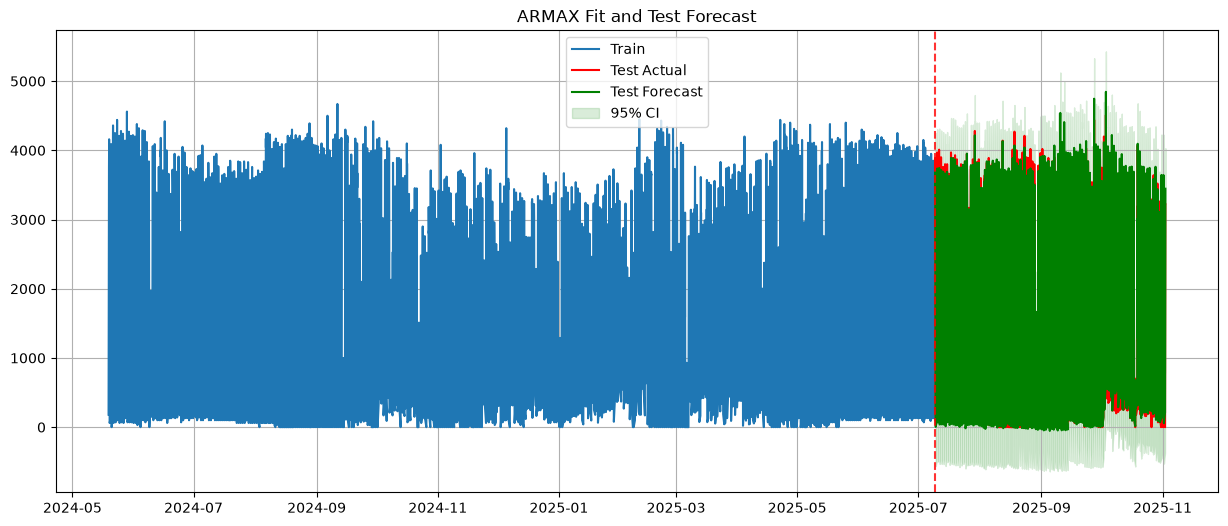

In [10]:
forecast_res = final_model.get_forecast(steps=len(test_series), exog=test_exog)
pred_test = forecast_res.predicted_mean
pred_test.index = test_df.index

conf_int = forecast_res.conf_int()
conf_int.index = test_df.index

plt.figure(figsize=(15, 6))
plt.plot(train_df.index, train_df['DC'], label='Train')
plt.plot(test_df.index, test_df['DC'], label='Test Actual', color='red')
plt.plot(pred_test.index, pred_test, label='Test Forecast', color='green')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                  color='green', alpha=0.15, label='95% CI')
plt.axvline(split_time_1, color='red', linestyle='--', alpha=0.8)
plt.title('ARMAX Fit and Test Forecast')
plt.legend()
plt.grid(True)
plt.show()

## Model diagnostics

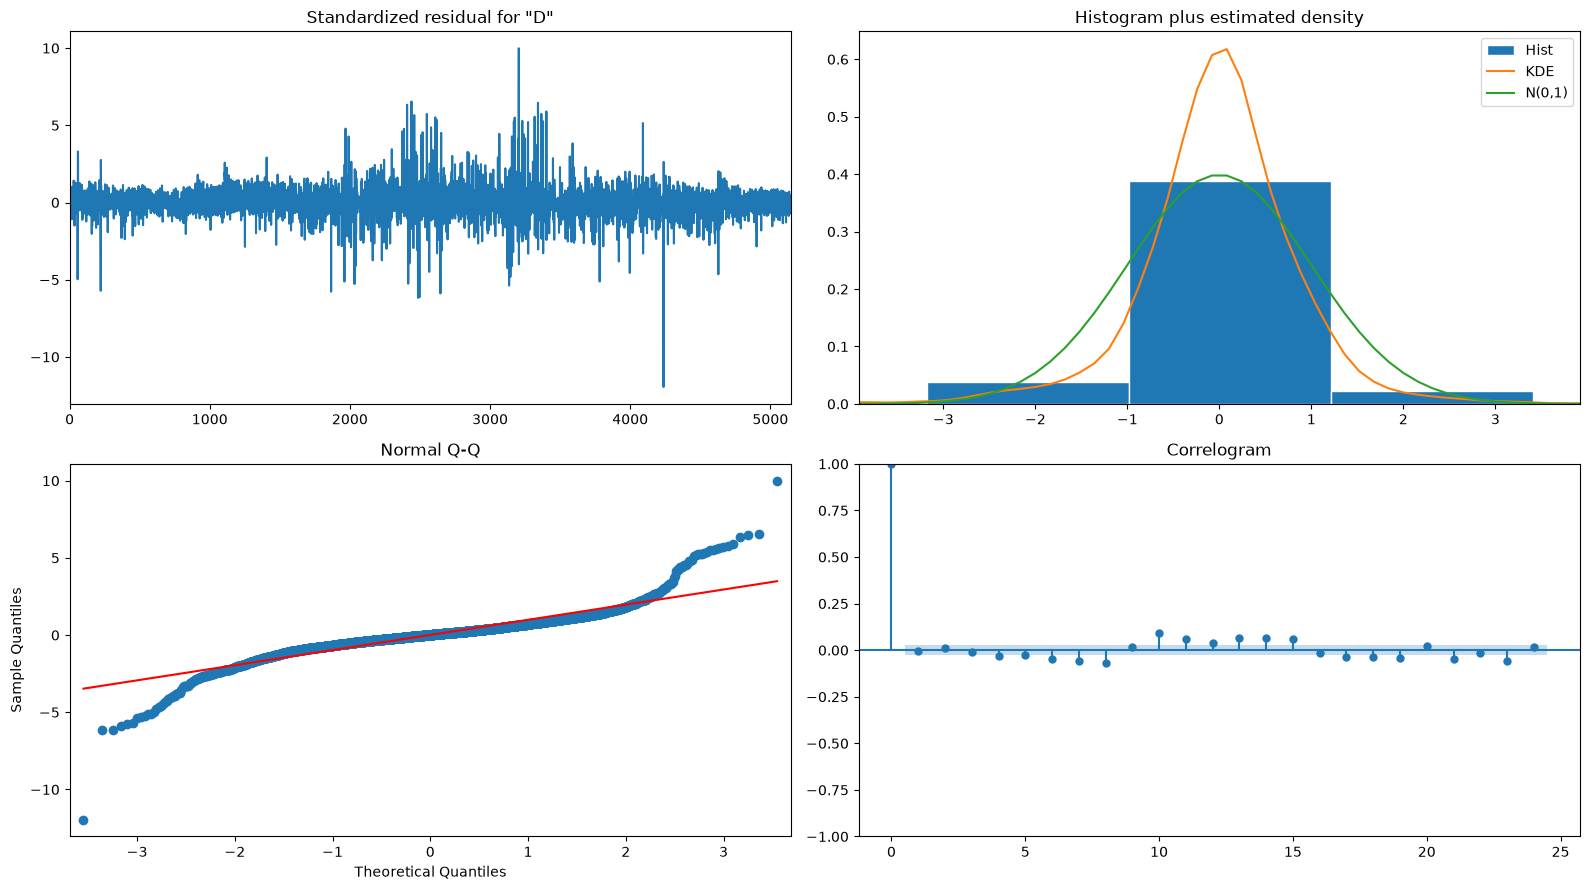

In [11]:
fig = plt.figure(figsize=(16, 9))
fig = final_model.plot_diagnostics(fig=fig, lags=24)
plt.tight_layout()
plt.show()

## Rolling one-step-ahead forecast on the test set

In [12]:
ac_full = pd.concat([train_df['DC'], test_df['DC']]).reset_index(drop=True)
exog_full = pd.concat([train_df[exog_cols], test_df[exog_cols]]).reset_index(drop=True)

ar_predictions = []
n_train = len(train_df)

for i in range(n_train, n_train + len(test_df)):
    updated_res = final_model.apply(ac_full[:i], exog=exog_full[:i])
    next_exog = exog_full.iloc[[i]]
    step_forecast = updated_res.get_forecast(steps=1, exog=next_exog)
    ar_predictions.append(step_forecast.predicted_mean.iloc[0])

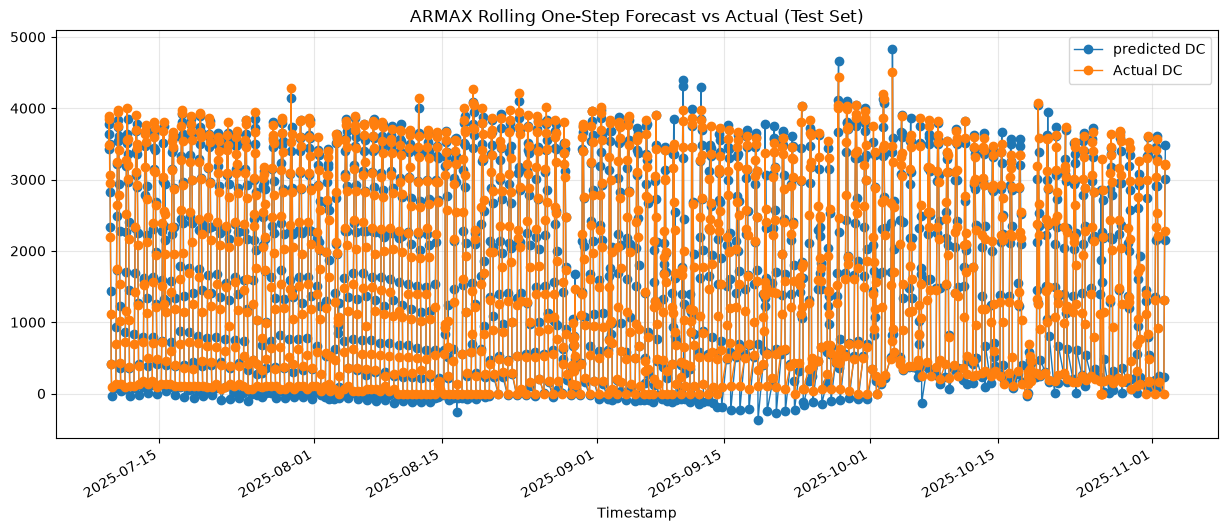

In [13]:
predictions = pd.DataFrame({
    "predicted DC": ar_predictions,
    "Actual DC": test_df['DC'].values,
}, index=test_df.index)

_, ax = plt.subplots(figsize=(15, 6))
predictions.plot(ax=ax, marker='o', linestyle='-', linewidth=1)
plt.title('ARMAX Rolling One-Step Forecast vs Actual (Test Set)')
plt.grid(True, alpha=0.3)
plt.show()

## Evaluation metrics

In [14]:
mse = mean_squared_error(predictions['Actual DC'], predictions['predicted DC'])
print('Test MSE: %.5f' % mse)

mape = np.mean(np.abs((predictions['Actual DC'] - predictions['predicted DC']) / (predictions['Actual DC'] + 1)))
print('Test MAPE-like: %.3f' % mape)

mae = mean_absolute_error(predictions['Actual DC'], predictions['predicted DC'])
print('Test MAE: %.3f' % mae)

r2 = r2_score(predictions['Actual DC'], predictions['predicted DC'])
print(f'R²: {r2:.3f}')

Test MSE: 67849.87629
Test MAPE-like: 9.124
Test MAE: 159.243
R²: 0.962


## Validation set forecast

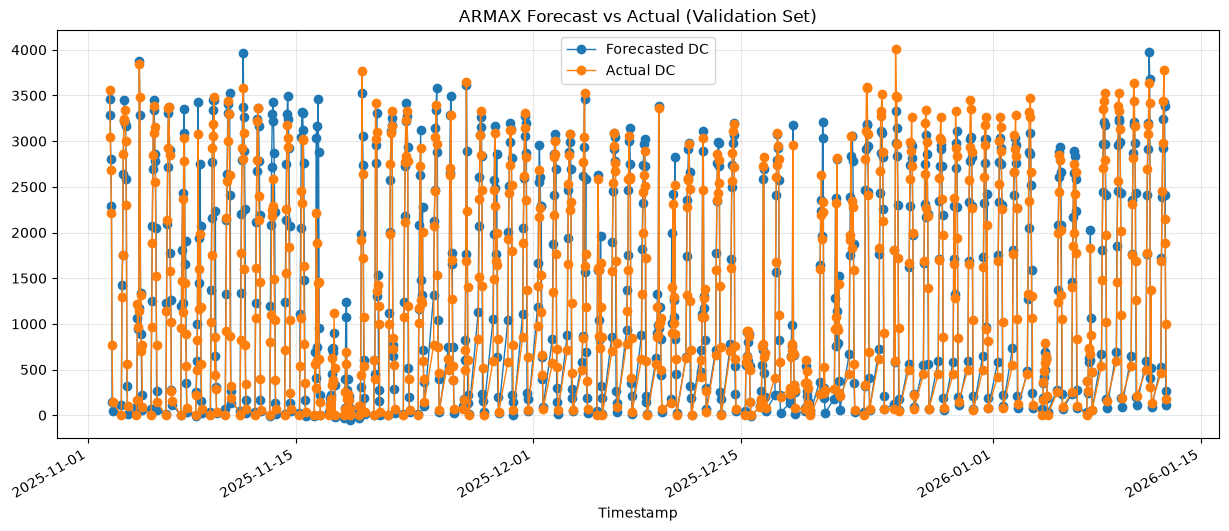

In [15]:
validation_exog = validation_df[exog_cols].reset_index(drop=True)

val_forecast_res = final_model.apply(ac_full, exog=exog_full).get_forecast(
    steps=len(validation_df), exog=validation_exog
)
forecast_values = val_forecast_res.predicted_mean
forecast_values.index = validation_df.index

predictions_val = pd.DataFrame({
    "Forecasted DC": forecast_values,
    "Actual DC": validation_df['DC'],
})

_, ax = plt.subplots(figsize=(15, 6))
predictions_val.plot(ax=ax, marker='o', linestyle='-', linewidth=1)
plt.title('ARMAX Forecast vs Actual (Validation Set)')
plt.grid(True, alpha=0.3)
plt.show()

### Save the ARMAX model

In [16]:
import os

os.makedirs("../models", exist_ok=True)
final_model.save("../models/armax_model.pkl")
print("Saved ARMAX model to ../models/armax_model.pkl")

Saved ARMAX model to ../models/armax_model.pkl
